# VGG16 for Banana Harvesting Dataset D2 - Keras/TensorFlow 2.x

This notebook integrates the Banana Harvesting Dataset (D2) into a Keras/TensorFlow VGG16 training workflow converted from `VGG16_Banana_Harvesting_D2.ipynb`.

Reference facts used from the provided files:
- `Analyze_dataset.ipynb` output: dataset root is `/content/Harvesting_Dataset` with two class folders, `Cut` and `Keep`, containing 2,685 `.jpg` files total.
- `Báo_cáo_đồ_án_CV.pdf`: binary RGB image classification, class `CUT` has 1,143 images and class `KEEP` has 1,542 images, split 70/15/15 into train/validation/test.
- `VGG16.ipynb`: model definition is VGG16 with only the final classifier changed, optimized by Adam with learning rate `2e-4` for `150` epochs.

No dataset download is performed here. Set `DATA_ROOT` to an existing extracted dataset directory when running outside Colab.


In [1]:
!gdown 1U_ISzUl8noFYP14Cx0X32tYBKkp_iIwF
!unzip -q -o /content/Harvesting_Dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1U_ISzUl8noFYP14Cx0X32tYBKkp_iIwF
From (redirected): https://drive.google.com/uc?id=1U_ISzUl8noFYP14Cx0X32tYBKkp_iIwF&confirm=t&uuid=ff58637d-2e89-4290-91e0-f8332a5d361c
To: /content/Harvesting_Dataset.zip
100% 4.84G/4.84G [00:46<00:00, 104MB/s] 


## Setup


In [3]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight


from huggingface_hub import notebook_login
from datasets import load_dataset

try:
    from sklearn.metrics import confusion_matrix, classification_report
except ImportError:
    confusion_matrix = None
    classification_report = None

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

SEED = 1
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

notebook_login()


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Dataset Configuration


In [4]:
DATA_ROOT = Path('/content/Harvesting_Dataset')

CLASS_TO_IDX = {
    'Cut': 0,
    'Keep': 1,
}
IDX_TO_CLASS = {idx: name.upper() for name, idx in CLASS_TO_IDX.items()}
EXPECTED_COUNTS = {'Cut': 1143, 'Keep': 1542}
EXPECTED_TOTAL = 2685

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
IMG_SIZE = (256, 256)
INPUT_SHAPE = (256, 256, 3)
BATCH_SIZE = 64
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MAX_EPOCHS = 50
LEARNING_RATE = 2e-4
AUTOTUNE = tf.data.AUTOTUNE

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9
print('Dataset root:', DATA_ROOT)
print('Expected structure:', [str(DATA_ROOT / class_name) for class_name in CLASS_TO_IDX])


Dataset root: /content/Harvesting_Dataset
Expected structure: ['/content/Harvesting_Dataset/Cut', '/content/Harvesting_Dataset/Keep']


## Dataset Loader


In [5]:
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "TRAIN_RATIO + VAL_RATIO + TEST_RATIO phải bằng 1.0"

TEMP_RATIO = VAL_RATIO + TEST_RATIO
VAL_FROM_TEMP_RATIO = VAL_RATIO / TEMP_RATIO

print(f"\n--- Loading Data from: {DATA_ROOT} ---")

# ============================================================
# 1. Generator tạm để tính mean / variance từ TRAIN SET
#    Không augmentation, chỉ rescale về [0, 1]
# ============================================================
stats_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=TEMP_RATIO
)

stats_it = stats_gen.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=False,
    seed=SEED
)

print("Đang tính mean và variance từ train dataset...")

channel_sum = np.zeros(3, dtype=np.float64)
channel_sum_sq = np.zeros(3, dtype=np.float64)
num_pixels = 0

for i in range(len(stats_it)):
    batch_x, _ = stats_it[i]   # batch_x shape: (B, H, W, 3), đã rescale [0,1]

    channel_sum += np.sum(batch_x, axis=(0, 1, 2))
    channel_sum_sq += np.sum(np.square(batch_x), axis=(0, 1, 2))
    num_pixels += batch_x.shape[0] * batch_x.shape[1] * batch_x.shape[2]

train_mean = channel_sum / num_pixels
train_var = (channel_sum_sq / num_pixels) - np.square(train_mean)
train_std = np.sqrt(train_var + 1e-7)

print(f"Train mean: {train_mean}")
print(f"Train variance: {train_var}")
print(f"Train std: {train_std}")


# ============================================================
# 2. Hàm normalize dùng mean/std của TRAIN SET
#    Input từ ImageDataGenerator là ảnh raw [0,255]
# ============================================================
def normalize_with_train_stats(img):
    img = img / 255.0
    img = (img - train_mean) / train_std
    return img


# ============================================================
# 3. Generator chính cho TRAIN, có augmentation + normalize
# ============================================================
train_aug = ImageDataGenerator(
    preprocessing_function=normalize_with_train_stats,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    rotation_range=20,
    fill_mode='nearest',
    validation_split=TEMP_RATIO
)

# Generator không augmentation, dùng để lấy temp Val + Test
# Có normalize để nhất quán, dù ở dưới ta chỉ lấy paths/classes
no_aug = ImageDataGenerator(
    preprocessing_function=normalize_with_train_stats,
    validation_split=TEMP_RATIO
)


# Load tập Train
train_it = train_aug.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=SEED
)

# Load tập tạm gồm Val + Test
temp_it = no_aug.flow_from_directory(
    DATA_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=SEED
)


# ============================================================
# 4. XỬ LÝ CHIA VAL / TEST
# ============================================================
temp_paths = np.array(temp_it.filepaths)
temp_labels = np.array(temp_it.classes)

rng = np.random.default_rng(SEED)
indices = rng.permutation(len(temp_paths))

temp_paths = temp_paths[indices]
temp_labels = temp_labels[indices]

val_size = int(len(temp_paths) * VAL_FROM_TEMP_RATIO)

val_paths, val_labels = temp_paths[:val_size], temp_labels[:val_size]
test_paths, test_labels = temp_paths[val_size:], temp_labels[val_size:]

print("-" * 30)
print(f"Train ratio: {TRAIN_RATIO:.2f}")
print(f"Val ratio  : {VAL_RATIO:.2f}")
print(f"Test ratio : {TEST_RATIO:.2f}")
print("-" * 30)
print(f"Train size: {train_it.samples}")
print(f"Val size  : {len(val_paths)} "
      f"(Class 0: {np.sum(val_labels == 0)}, Class 1: {np.sum(val_labels == 1)})")
print(f"Test size : {len(test_paths)} "
      f"(Class 0: {np.sum(test_labels == 0)}, Class 1: {np.sum(test_labels == 1)})")
print("-" * 30)


# ============================================================
# 5. Tính Class Weights
# ============================================================
train_labels = train_it.classes

try:
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"⚖️ Class Weights: {class_weights_dict}")
except Exception as e:
    print(f"⚠️ Không thể tính Class Weights: {e}")
    class_weights_dict = None


# ============================================================
# 6. Hàm tạo tf.data cho Validation và Test
#    Dùng cùng train_mean / train_std
# ============================================================
train_mean_tf = tf.constant(train_mean, dtype=tf.float32)
train_std_tf = tf.constant(train_std, dtype=tf.float32)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    img = (img - train_mean_tf) / train_std_tf

    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    label = tf.cast(label, tf.float32)

    return img, label


def make_ds(paths, labels, batch=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


print("Đang tạo tf.data cho Validation và Test...")
val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)

print("✅ Hoàn tất tiền xử lý dữ liệu!")


--- Loading Data from: /content/Harvesting_Dataset ---
Found 1881 images belonging to 2 classes.
Đang tính mean và variance từ train dataset...
Train mean: [0.38542532 0.45988118 0.27890236]
Train variance: [0.05489612 0.05486655 0.06991387]
Train std: [0.23429943 0.23423632 0.26441249]
Found 1881 images belonging to 2 classes.
Found 804 images belonging to 2 classes.
------------------------------
Train ratio: 0.70
Val ratio  : 0.15
Test ratio : 0.15
------------------------------
Train size: 1881
Val size  : 402 (Class 0: 175, Class 1: 227)
Test size : 402 (Class 0: 167, Class 1: 235)
------------------------------
⚖️ Class Weights: {0: np.float64(1.1741573033707866), 1: np.float64(0.8708333333333333)}
Đang tạo tf.data cho Validation và Test...
✅ Hoàn tất tiền xử lý dữ liệu!


## Model


In [22]:
def build_vgg16_sigmoid(
    input_shape=(256, 256, 3),
    num_classes=1
):
    base = tf.keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base(inputs)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    return model

In [23]:
model = build_vgg16_sigmoid(
    input_shape=INPUT_SHAPE,
    num_classes=1
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Training Utilities


In [24]:
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

checkpoint_path = Path('vgg16_banana_harvesting_d2_best.keras')
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


def collect_predictions(model, dataset):
    probabilities = model.predict(dataset, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true_batches = [labels.numpy() for _, labels in dataset]
    y_true = np.concatenate(y_true_batches, axis=0)
    return y_true, y_pred


## Train


In [25]:
history = model.fit(
    train_it,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weights_dict,
)

train_losses = history.history['loss']
train_accuracies = [value * 100 for value in history.history['accuracy']]
val_losses = history.history['val_loss']
val_accuracies = [value * 100 for value in history.history['val_accuracy']]
best_val_accuracy = max(val_accuracies)

print(f'Best validation accuracy: {best_val_accuracy:.2f}%')


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4999 - loss: 0.7121
Epoch 1: val_accuracy improved from None to 0.64179, saving model to vgg16_banana_harvesting_d2_best.keras

Epoch 1: finished saving model to vgg16_banana_harvesting_d2_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 117s 4s/step - accuracy: 0.5189 - loss: 0.6976 - val_accuracy: 0.6418 - val_loss: 0.6437 - learning_rate: 2.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6260 - loss: 0.6556
Epoch 2: val_accuracy improved from 0.64179 to 0.70647, saving model to vgg16_banana_harvesting_d2_best.keras

Epoch 2: finished saving model to vgg16_banana_harvesting_d2_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.6108 - loss: 0.6571 - val_accuracy: 0.7065 - val_loss: 0.6309 - learning_rate: 2.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6730 - loss: 0.6330
Epoch 3: val_accuracy did not improve from 0.70647
30/30 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accurac

## Test Evaluation



--- Đang tìm Threshold tối ưu trên tập Valid ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 290ms/step

🏆 BEST THRESHOLD (Validation):
{'thr': np.float64(0.45000000000000007), 'precision': np.float64(0.7655677655649613), 'recall': np.float64(0.920704845810922), 'f1': np.float64(0.8359999995008879), 'acc': np.float64(0.7960199004955323), 'specificity': np.float64(0.6342857142820898)}

--- Đánh giá trên tập TEST với Threshold đã chọn ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step
Chosen Threshold: 0.4500
Test Accuracy   : 0.8109
Test F1-Score   : 0.8455
Test Precision  : 0.8093
Test Recall     : 0.8851
Test Specificity: 0.7066


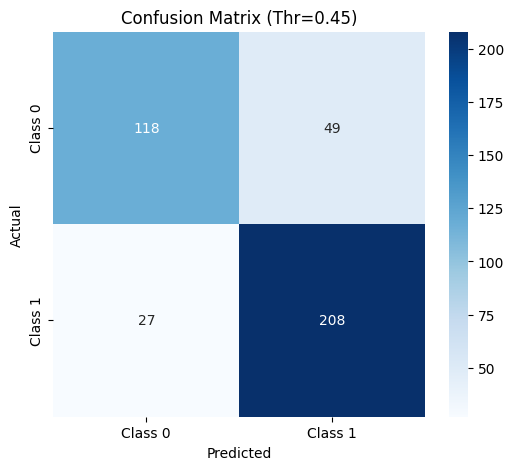

In [26]:
if checkpoint_path.exists():
    model = keras.models.load_model(checkpoint_path)

# ==========================================
# 5) FINE-TUNING THRESHOLD & TEST
# ==========================================

def metrics_at_thr(y_true, y_prob, thr):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).ravel()

    y_hat = (y_prob >= thr).astype(int)

    tp = np.sum((y_hat == 1) & (y_true == 1))
    tn = np.sum((y_hat == 0) & (y_true == 0))
    fp = np.sum((y_hat == 1) & (y_true == 0))
    fn = np.sum((y_hat == 0) & (y_true == 1))

    precision   = tp / (tp + fp + 1e-9)
    recall      = tp / (tp + fn + 1e-9)
    f1          = 2 * precision * recall / (precision + recall + 1e-9)
    acc         = (tp + tn) / (tp + tn + fp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    return precision, recall, f1, acc, specificity


print("\n--- Đang tìm Threshold tối ưu trên tập Valid ---")

val_probs = model.predict(val_ds, verbose=1).ravel()
val_y = val_labels.astype(int)

ths = np.linspace(0.1, 0.9, 81)
best = None

for t in ths:
    prec, rec, f1, acc, spe = metrics_at_thr(val_y, val_probs, t)

    # Ưu tiên F1 Score
    if best is None or f1 > best["f1"]:
        best = {
            "thr": t,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "acc": acc,
            "specificity": spe
        }

print("\n🏆 BEST THRESHOLD (Validation):")
print(best)


# --- ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\n--- Đánh giá trên tập TEST với Threshold đã chọn ---")

test_probs = model.predict(test_ds, verbose=1).ravel()
test_y = test_labels.astype(int)

thr = best["thr"]
prec, rec, f1, acc, spe = metrics_at_thr(test_y, test_probs, thr)

print(f"Chosen Threshold: {thr:.4f}")
print(f"Test Accuracy   : {acc:.4f}")
print(f"Test F1-Score   : {f1:.4f}")
print(f"Test Precision  : {prec:.4f}")
print(f"Test Recall     : {rec:.4f}")
print(f"Test Specificity: {spe:.4f}")


# Confusion Matrix
y_hat_test = (test_probs >= thr).astype(int)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_y, y_hat_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Thr={thr:.2f})')
plt.show()

## Plot Results


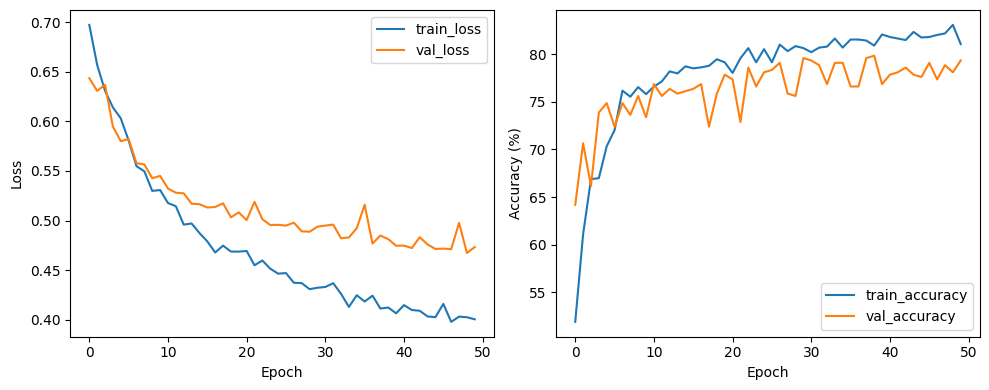

In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='train_accuracy')
plt.plot(val_accuracies, label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()


## Optional Checkpoint Save


In [28]:
metadata_path = Path('vgg16_banana_harvesting_d2_metadata.npz')
model.save(checkpoint_path)
np.savez(
    metadata_path,
    class_names=np.array([IDX_TO_CLASS[i] for i in range(len(IDX_TO_CLASS))]),
    class_to_idx=np.array(list(CLASS_TO_IDX.items()), dtype=object),
    img_size=np.array([IMG_SIZE], dtype=np.int32),
    normalization_mean=train_mean,
    normalization_std=train_std,
    best_val_accuracy=np.array([best_val_accuracy], dtype=np.float32),
)
print('Saved model:', checkpoint_path)
print('Saved metadata:', metadata_path)

notebook_login()

# Save and upload directly to Hugging Face Hub
model.save("hf://ez4kacchan/banana-harvesting-vgg16-final3")

Saved model: vgg16_banana_harvesting_d2_best.keras
Saved metadata: vgg16_banana_harvesting_d2_metadata.npz


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...hqlzzpk6/model.weights.h5:  97%|#########6| 58.6MB / 60.5MB            

  ...6/assets/summary_plot.png:  28%|##7       | 41.0kB /  149kB            

Model saved to the Hugging Face Hub: https://huggingface.co/ez4kacchan/banana-harvesting-vgg16-final3
To load back the model, use `keras.saving.load_model('hf://ez4kacchan/banana-harvesting-vgg16-final3')`
